# Proyecto 2 · C1: ingeniería de datos y secuencias
**José Auyón · CC3092 Deep Learning**

Este notebook ejecuta C1 desde los CSV originales, documenta las decisiones y entrega el mismo contrato a la etapa A, etapa B, línea base y MVP. Las gráficas aparecen antes de cualquier modelado.

La comparación detallada de PaySim y las seis variantes IBM está en `notebooks/comparacion_datasets.ipynb`. PaySim se mantiene como análisis exploratorio; IBM AML HI-Small se usa para modelar porque ofrece historiales por remitente. Fraude y lavado son etiquetas distintas y no se mezclan.

## Decisiones de diseño

- Selección uniforme de 50,000 cuentas emisoras, semilla 42 y sin consultar labels.
- Historial ordenado por tiempo; empate resuelto por el índice original de fila.
- Últimas 64 operaciones. La etiqueta se recalcula después del recorte.
- Secuencia por cuenta; split por `Entity ID` para mantener juntas las cuentas del mismo actor.
- Features causales: monto, ritmo, frecuencia, tiempo, banco, repetición de destinatario, moneda y formato.
- Estadísticas numéricas ajustadas solo con normalidad de entrenamiento; vocabularios ajustados con todo entrenamiento.
- Prevalencia natural, sin SMOTE. `pos_weight` se entrega para que C2B decida cómo usarlo.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "data" / "sequences.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Ejecutar desde la raíz del proyecto o desde notebooks/")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.sequences import build_artifacts, get_sender, make_dataloaders

CSV_PATH = ROOT / "datasets" / "IBM" / "HI-Small_Trans.csv"
ARTIFACT_DIR = ROOT / "artifacts" / "c1_hi_small"
REPORT_DIR = ROOT / "reports" / "c1"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
if not CSV_PATH.is_file():
    raise FileNotFoundError(f"Falta {CSV_PATH}")
print(f"Proyecto: {ROOT}")
print(f"Fuente: {CSV_PATH.name} ({CSV_PATH.stat().st_size / 1e9:.2f} GB)")

Proyecto: /Users/joseruiz_002/Documents/UVG/8to Semestre/Deep Learning/Proyecto2_DL
Fuente: HI-Small_Trans.csv (0.48 GB)


## Construcción reproducible

La celda lee `HI-Small_Trans.csv` completo dos veces: primero valida todas las filas y selecciona remitentes; después conserva sus historiales. También valida y cruza Accounts. Sobrescribe únicamente los cinco artefactos conocidos dentro de `artifacts/c1_hi_small`.

In [2]:
manifest = build_artifacts(
    CSV_PATH,
    ARTIFACT_DIR,
    n_senders=50_000,
    max_len=64,
    seed=42,
)
print(f"Pipeline completo: {manifest['runtime']['total_seconds']:.1f} s")
print(f"Contrato v{manifest['contract_version']} · {len(manifest['feature_names'])} features")

Pipeline completo: 54.3 s
Contrato v1 · 33 features


## Resumen de selección, recorte y clases

In [3]:
counts = manifest["counts"]
summary_rows = [
    ("Fuente completa", counts["source_transactions"], counts["source_senders"]),
    ("Muestra antes del recorte", counts["selected_transactions_before_truncation"], counts["selected_senders"]),
    ("Muestra después del recorte", counts["retained_transactions"], counts["selected_senders"]),
]
display(pd.DataFrame(summary_rows, columns=["Estado", "Transacciones", "Remitentes"]))
display(pd.DataFrame([
    {
        "Estado": "Antes del recorte",
        "Remitentes positivos": counts["positive_senders_before_truncation"],
        "Transacciones positivas": counts["positive_transactions_before_truncation"],
    },
    {
        "Estado": "Después del recorte",
        "Remitentes positivos": counts["positive_senders_after_truncation"],
        "Transacciones positivas": counts["positive_transactions_after_truncation"],
    },
]))
print(f"Remitentes recortados: {counts['truncated_senders']:,} ({100*counts['truncated_senders']/counts['selected_senders']:.3f}%)")

,Estado,Transacciones,Remitentes
0,Fuente completa,5078345,496999
1,Muestra antes del recorte,464009,50000
2,Muestra después del recorte,426244,50000


,Estado,Remitentes positivos,Transacciones positivas
0,Antes del recorte,366,533
1,Después del recorte,362,525


Remitentes recortados: 1,307 (2.614%)


## Distribución de longitudes

La longitud original cuenta todas las operaciones del remitente seleccionado. La longitud retenida proviene de los offsets persistidos. El eje derecho amplía P90–P99 porque unos pocos historiales extremos hacen poco informativo el máximo.

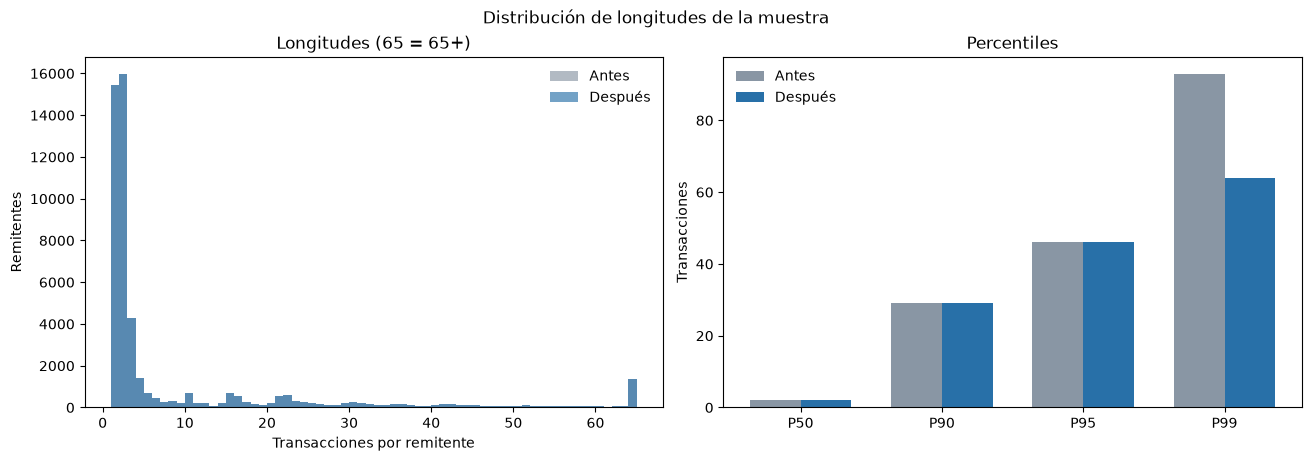

In [4]:
with np.load(ARTIFACT_DIR / manifest["artifacts"]["arrays"], allow_pickle=False) as loaded:
    arrays = {name: loaded[name] for name in loaded.files}
retained_lengths = np.diff(arrays["offsets"])
full_lengths = arrays["full_lengths"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
bins = np.arange(1, 66)
axes[0].hist(np.minimum(full_lengths, 65), bins=bins, alpha=.65, label="Antes", color="#8996a4")
axes[0].hist(np.minimum(retained_lengths, 65), bins=bins, alpha=.65, label="Después", color="#2870a8")
axes[0].set(title="Longitudes (65 = 65+)", xlabel="Transacciones por remitente", ylabel="Remitentes")
axes[0].legend(frameon=False)
quantiles = [50, 90, 95, 99]
before_q = np.percentile(full_lengths, quantiles, method="inverted_cdf")
after_q = np.percentile(retained_lengths, quantiles, method="inverted_cdf")
x = np.arange(len(quantiles))
width = .36
axes[1].bar(x-width/2, before_q, width, label="Antes", color="#8996a4")
axes[1].bar(x+width/2, after_q, width, label="Después", color="#2870a8")
axes[1].set(xticks=x, xticklabels=[f"P{q}" for q in quantiles], title="Percentiles", ylabel="Transacciones")
axes[1].legend(frameon=False)
fig.suptitle("Distribución de longitudes de la muestra")
fig.savefig(REPORT_DIR / "longitudes_secuencia.png", dpi=160)
plt.show()

## Splits sin entidades compartidas y prevalencia natural

,Split,Remitentes,Entidades,Positivos,% positivo
0,train,35000,29165,254,0.725714
1,validation,7500,1569,54,0.720000
2,test,7500,1569,54,0.720000


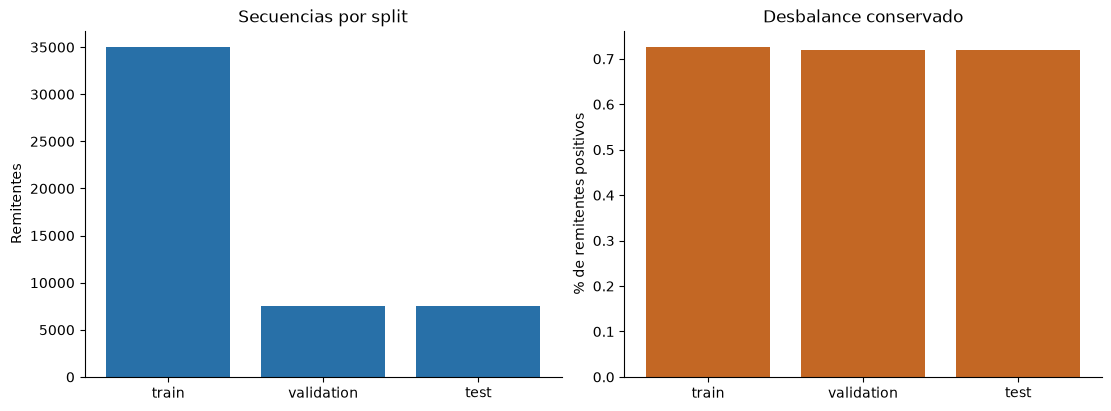

Entidades compartidas entre splits: 0 · pos_weight de entrenamiento: 136.7953


In [5]:
split_rows = []
for name in ("train", "validation", "test"):
    split = manifest["splits"][name]
    split_rows.append({
        "Split": name,
        "Remitentes": split["sender_count"],
        "Entidades": len(split["entity_ids"]),
        "Positivos": split["positive_sender_count"],
        "% positivo": 100 * split["positive_sender_count"] / split["sender_count"],
    })
split_frame = pd.DataFrame(split_rows)
display(split_frame)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].bar(split_frame["Split"], split_frame["Remitentes"], color="#2870a8")
axes[0].set(title="Secuencias por split", ylabel="Remitentes")
axes[1].bar(split_frame["Split"], split_frame["% positivo"], color="#c36724")
axes[1].set(title="Desbalance conservado", ylabel="% de remitentes positivos")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.savefig(REPORT_DIR / "splits_y_clases.png", dpi=160)
plt.show()

entity_sets = [set(manifest["splits"][name]["entity_ids"]) for name in ("train", "validation", "test")]
assert not (entity_sets[0] & entity_sets[1] or entity_sets[0] & entity_sets[2] or entity_sets[1] & entity_sets[2])
print(f"Entidades compartidas entre splits: 0 · pos_weight de entrenamiento: {counts['pos_weight']:.4f}")

## Representación por transacción

Las tres primeras variables se estandarizan. Las variables de tiempo son cíclicas; los indicadores y one-hot permanecen en su escala natural. La columna `<UNK>` permite inferencia con categorías ausentes durante entrenamiento.

In [6]:
preprocessor = json.loads((ARTIFACT_DIR / manifest["artifacts"]["preprocessor"]).read_text(encoding="utf-8"))
display(pd.DataFrame({
    "Feature numérica": preprocessor["numeric_features"],
    "Media train normal": preprocessor["numeric_mean"],
    "Escala train normal": preprocessor["numeric_scale"],
}))
display(pd.DataFrame({"Índice": range(len(manifest["feature_names"])), "Feature": manifest["feature_names"]}))

,Feature numérica,Media train normal,Escala train normal
0,log_amount_paid,7.515121,3.192622
1,log_delta_hours,1.142519,1.413100
2,log_previous_24h,1.264543,0.849074


,Índice,Feature
0,0,log_amount_paid_z
1,1,log_delta_hours_z
2,2,log_previous_24h_z
3,3,hour_sin
4,4,hour_cos
5,5,weekday_sin
6,6,weekday_cos
7,7,cross_bank
8,8,destination_seen_before
9,9,currency=<UNK>


## Tres pares de secuencias normales y sospechosas

Se eligen de entrenamiento con longitud mínima de tres y semilla fija. Cada panel conserva el orden temporal. Los puntos rojos indican transacciones con label de lavado; las líneas pueden unir importes expresados en monedas diferentes y sirven para mostrar el patrón temporal, no para sumar valor económico entre monedas.

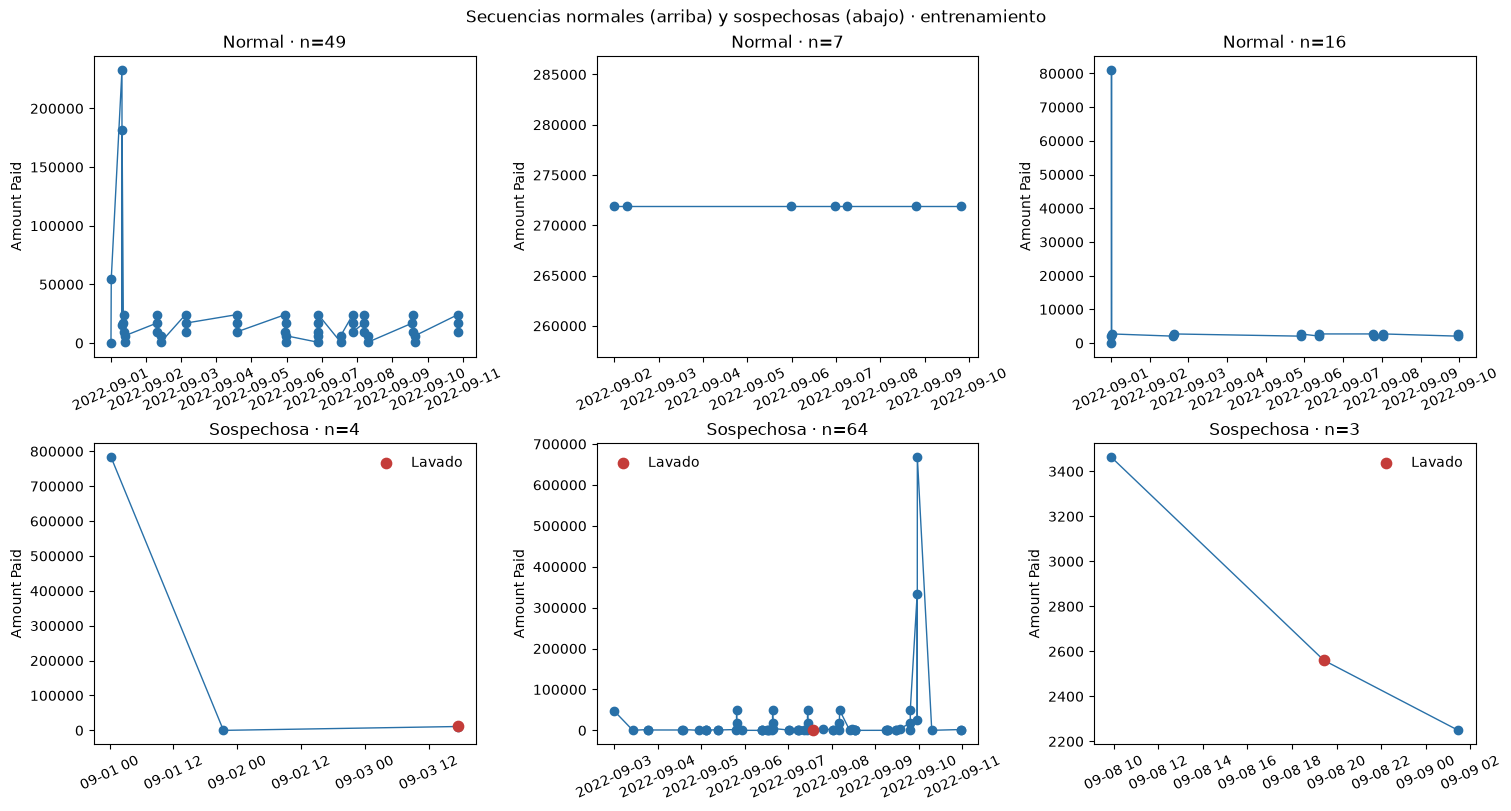

In [7]:
rng = np.random.default_rng(42)
train_indices = np.flatnonzero(arrays["split_codes"] == 0)
eligible = train_indices[retained_lengths[train_indices] >= 3]
positive = eligible[arrays["y"][eligible] == 1]
negative = eligible[arrays["y"][eligible] == 0]
chosen = np.concatenate([rng.choice(negative, 3, replace=False), rng.choice(positive, 3, replace=False)])

fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout="constrained")
for panel, index in zip(axes.flat, chosen):
    sender_id = str(arrays["sender_ids"][index])
    sample = get_sender(sender_id, ARTIFACT_DIR, split="train")
    frame = pd.DataFrame(sample["transactions"])
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], format="%Y/%m/%d %H:%M")
    panel.plot(frame["timestamp"], frame["amount_paid"], marker="o", color="#2870a8", linewidth=1)
    suspicious = frame["is_laundering"] == 1
    panel.scatter(frame.loc[suspicious, "timestamp"], frame.loc[suspicious, "amount_paid"], color="#c43c39", s=55, zorder=3, label="Lavado")
    panel.set_title(("Normal" if sample["y"].item() == 0 else "Sospechosa") + f" · n={len(frame)}")
    panel.set_ylabel("Amount Paid")
    panel.tick_params(axis="x", rotation=25)
    if suspicious.any():
        panel.legend(frameon=False)
fig.suptitle("Secuencias normales (arriba) y sospechosas (abajo) · entrenamiento")
fig.savefig(REPORT_DIR / "ejemplos_secuencias.png", dpi=160)
plt.show()

In [8]:
loaders = make_dataloaders(ARTIFACT_DIR, batch_size=128, seed=42)
example = next(iter(loaders["train_normal"]))
display(pd.DataFrame([
    {"Campo": "x", "Forma": str(tuple(example["x"].shape)), "Tipo": str(example["x"].dtype)},
    {"Campo": "mask", "Forma": str(tuple(example["mask"].shape)), "Tipo": str(example["mask"].dtype)},
    {"Campo": "lengths", "Forma": str(tuple(example["lengths"].shape)), "Tipo": str(example["lengths"].dtype)},
    {"Campo": "y", "Forma": str(tuple(example["y"].shape)), "Tipo": str(example["y"].dtype)},
    {"Campo": "transaction_ids", "Forma": str(tuple(example["transaction_ids"].shape)), "Tipo": str(example["transaction_ids"].dtype)},
]))
assert not example["y"].bool().any()
assert (example["mask"].sum(axis=1) == example["lengths"]).all()
assert (example["transaction_ids"][~example["mask"]] == -1).all()
print("train_normal contiene solo normalidad; máscara y padding son coherentes.")

,Campo,Forma,Tipo
0,x,"(128, 64, 33)",torch.float32
1,mask,"(128, 64)",torch.bool
2,lengths,"(128,)",torch.int64
3,y,"(128,)",torch.float32
4,transaction_ids,"(128, 64)",torch.int64


train_normal contiene solo normalidad; máscara y padding son coherentes.


## Validación de integridad

Estas comprobaciones no sustituyen las pruebas unitarias. Verifican el artefacto real generado en esta ejecución.

In [9]:
assert arrays["x_values"].dtype == np.float32
assert np.isfinite(arrays["x_values"]).all()
assert len(arrays["sender_ids"]) == 50_000
assert len(set(arrays["sender_ids"].tolist())) == 50_000
assert arrays["offsets"][-1] == len(arrays["x_values"]) == counts["retained_transactions"]
assert set(np.unique(arrays["y"])).issubset({0.0, 1.0})
assert int(arrays["y"].sum()) == counts["positive_senders_after_truncation"]
assert arrays["transaction_ids"].size == np.unique(arrays["transaction_ids"]).size
assert len(manifest["source"]["transactions_sha256"]) == 64
assert len(manifest["source"]["accounts_sha256"]) == 64
print("Artefactos reales: IDs únicos, shapes, labels, offsets, valores finitos y huellas válidas.")

Artefactos reales: IDs únicos, shapes, labels, offsets, valores finitos y huellas válidas.


## Limitaciones de C1

- IBM AML es sintético y no representa directamente el corredor Guatemala–Estados Unidos.
- `y=0` significa que no hay una operación etiquetada dentro del historial retenido; no certifica legitimidad.
- La división generaliza a entidades no vistas, pero no es prospectiva en el tiempo.
- Destinatarios y bancos sí pueden aparecer en varios splits.
- El recorte elimina cuatro remitentes positivos y ocho transacciones positivas de la muestra.
- El archivo completo del notebook debe volver a medirse en Colab T4 cuando C2A, C2B y la ablación estén integrados.

# C2A — Etapa A: aprendizaje de la normalidad

**Autor de esta sección: Jose Ruiz.**

## Decisiones de diseño

La Etapa A debe procesar secuencias de longitud variable, comprimirlas en una representación y reconstruirlas, sin usar `y`. Se implementó un **autoencoder Transformer con máscara de padding** (`src/models/stage_a.py`):

- **Encoder:** proyección lineal de las 33 features a `d_model=64`, codificación posicional senoidal y `nn.TransformerEncoder` (2 capas, 4 cabezas) con `src_key_padding_mask` para ignorar el padding de `mask`.
- **Pooling por atención:** un query aprendido atiende sobre las posiciones válidas del encoder para producir `z`, el vector comprimido del comportamiento del remitente.
- **Decoder:** `z` se difunde a las 64 posiciones, se le suma la misma codificación posicional y otro `nn.TransformerEncoder` (2 capas) reconstruye `x_hat`.
- **Score de anomalía:** error cuadrático medio por secuencia, enmascarado para ignorar el padding (`masked_reconstruction_error`).

Se eligió un Transformer y no un GRU/LSTM porque (a) la Etapa B reutilizará este encoder por transfer learning, y su atención puede servir como insumo adicional de interpretabilidad; y (b) con secuencias cortas (máx. 64 pasos) el costo cuadrático de la atención es irrelevante frente al beneficio de capturar dependencias entre transacciones no necesariamente consecutivas (p. ej. fragmentación de montos con transacciones intercaladas).

**Entrenamiento:** `train_stage_a` itera exclusivamente `loaders["train_normal"]` (34,746 secuencias, todas `y=0`). La AUC-PR de validación se calcula cada época solo para elegir el mejor checkpoint — nunca participa en el gradiente — porque con ~0.72% de positivos en validación (54/7,500) la pérdida de reconstrucción por sí sola no distingue si el modelo está aprendiendo algo útil para separar clases.

**Umbral:** se barre la curva precisión-recall de validación y se elige el punto que maximiza F1 (`select_threshold`). Con esta prevalencia, exactitud o un percentil fijo no son justificables — casi cualquier umbral tiene accuracy >99% con recall≈0 — así que se reporta F1 como métrica principal, y AUC-PR como medida de separabilidad independiente del umbral.

In [10]:
import torch

from src.models.stage_a import (
    StageAConfig,
    anomaly_score,
    resolve_device,
    save_checkpoint,
    score_loader,
    select_threshold,
    train_stage_a,
)
from sklearn.metrics import confusion_matrix, precision_recall_curve

REPORT_DIR_C2A = ROOT / "reports" / "c2a"
REPORT_DIR_C2A.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = ROOT / "artifacts" / "checkpoints" / "stage_a.pt"

stage_a_config = StageAConfig(feature_dim=len(manifest["feature_names"]), max_len=manifest["configuration"]["max_len"], seed=42)
print(f"device: {resolve_device()} · feature_dim={stage_a_config.feature_dim} · max_len={stage_a_config.max_len}")

device: mps · feature_dim=33 · max_len=64


In [11]:
import time

start = time.perf_counter()
stage_a_model, stage_a_history = train_stage_a(loaders, stage_a_config, epochs=10, device=None, log_every=1)
stage_a_train_seconds = time.perf_counter() - start
print(f"\nEntrenamiento completo: {stage_a_train_seconds:.1f} s · mejor época por AUC-PR de validación: {stage_a_history.best_epoch}")

epoch 00 | train_loss=0.09595 | validation_AP=0.0665


epoch 01 | train_loss=0.05632 | validation_AP=0.1091


epoch 02 | train_loss=0.04418 | validation_AP=0.1356


epoch 03 | train_loss=0.03932 | validation_AP=0.0969


epoch 04 | train_loss=0.03682 | validation_AP=0.0939


epoch 05 | train_loss=0.03498 | validation_AP=0.0690


epoch 06 | train_loss=0.03358 | validation_AP=0.0563


epoch 07 | train_loss=0.03248 | validation_AP=0.0496


epoch 08 | train_loss=0.03160 | validation_AP=0.0506


epoch 09 | train_loss=0.03085 | validation_AP=0.0511

Entrenamiento completo: 66.4 s · mejor época por AUC-PR de validación: 2


## Curvas de entrenamiento

La pérdida de reconstrucción (train_normal) baja monótonamente, pero la AUC-PR de validación alcanza su máximo temprano (época 2) y luego decae aunque la reconstrucción siga mejorando en general. Esto es honesto y esperable: el autoencoder se vuelve mejor reconstruyendo secuencias *en general*, incluidas algunas con patrones de lavado que no son tan distintas de la normalidad en las features disponibles. `train_stage_a` ya selecciona automáticamente el checkpoint de mejor AUC-PR, no el de menor pérdida final.

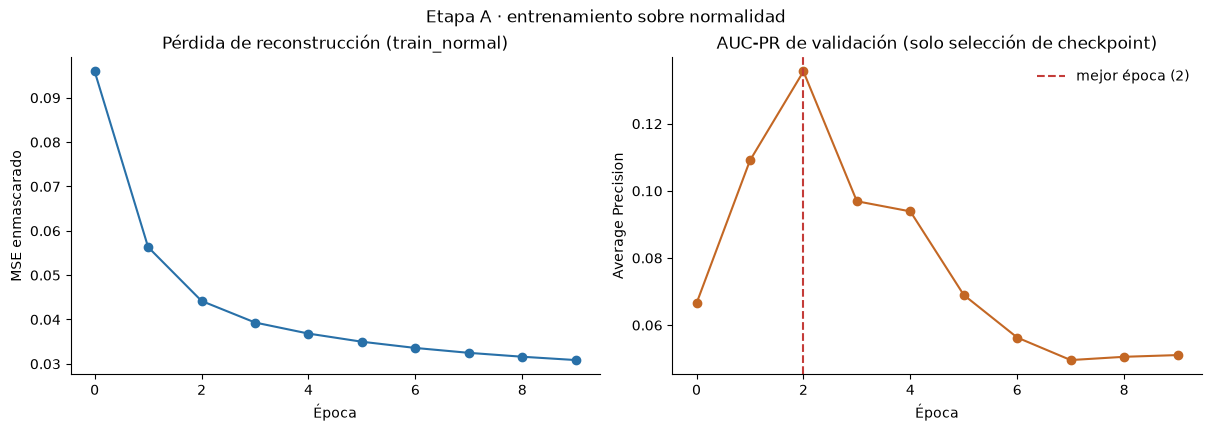

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")
epochs_x = range(len(stage_a_history.train_loss))
axes[0].plot(epochs_x, stage_a_history.train_loss, marker="o", color="#2870a8")
axes[0].set(title="Pérdida de reconstrucción (train_normal)", xlabel="Época", ylabel="MSE enmascarado")
axes[1].plot(epochs_x, stage_a_history.validation_average_precision, marker="o", color="#c36724")
axes[1].axvline(stage_a_history.best_epoch, color="#c43c39", linestyle="--", label=f"mejor época ({stage_a_history.best_epoch})")
axes[1].set(title="AUC-PR de validación (solo selección de checkpoint)", xlabel="Época", ylabel="Average Precision")
axes[1].legend(frameon=False)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Etapa A · entrenamiento sobre normalidad")
fig.savefig(REPORT_DIR_C2A / "curvas_entrenamiento.png", dpi=160)
plt.show()

## Umbral y evaluación

El umbral se elige **solo con el split de validación**; el conjunto de prueba se usa después, una única vez, para reportar el resultado final con ese umbral ya fijo.

In [13]:
device = resolve_device()
validation_scores = score_loader(stage_a_model, loaders["validation"], device)
threshold_info = select_threshold(validation_scores["score"], validation_scores["y"])

display(pd.DataFrame([{
    "Umbral (F1 óptimo)": threshold_info.threshold,
    "AUC-PR (validación)": threshold_info.average_precision,
    "Precisión": threshold_info.precision,
    "Recall": threshold_info.recall,
    "F1": threshold_info.f1,
}]))

baseline_ap = validation_scores["y"].mean()
print(f"AUC-PR de una alerta aleatoria (prevalencia): {baseline_ap:.4f} · Etapa A: {threshold_info.average_precision:.4f} "
      f"({threshold_info.average_precision / baseline_ap:.1f}x)")

,Umbral (F1 óptimo),AUC-PR (validación),Precisión,Recall,F1
0,0.172215,0.135582,0.5,0.185185,0.27027


AUC-PR de una alerta aleatoria (prevalencia): 0.0072 · Etapa A: 0.1356 (18.8x)


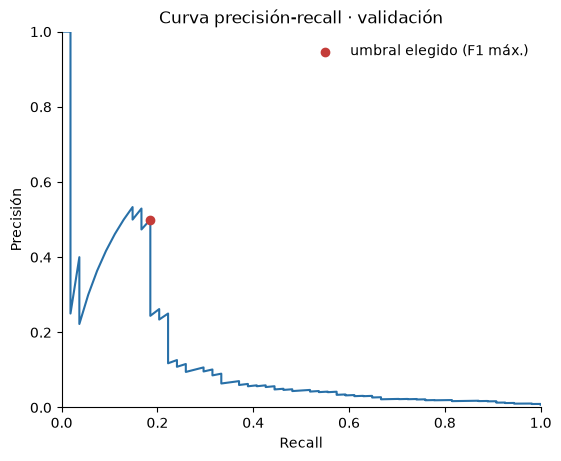

In [14]:
precision, recall, _ = precision_recall_curve(validation_scores["y"], validation_scores["score"])
fig, ax = plt.subplots(figsize=(5.5, 4.5), layout="constrained")
ax.plot(recall, precision, color="#2870a8")
ax.scatter([threshold_info.recall], [threshold_info.precision], color="#c43c39", zorder=3, label="umbral elegido (F1 máx.)")
ax.set(title="Curva precisión-recall · validación", xlabel="Recall", ylabel="Precisión", xlim=(0, 1), ylim=(0, 1))
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(REPORT_DIR_C2A / "curva_precision_recall.png", dpi=160)
plt.show()

In [15]:
test_scores = score_loader(stage_a_model, loaders["test"], device)
test_pred = (test_scores["score"] > threshold_info.threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(test_scores["y"], test_pred).ravel()
test_precision = tp / (tp + fp) if (tp + fp) else 0.0
test_recall = tp / (tp + fn) if (tp + fn) else 0.0
test_f1 = 2 * test_precision * test_recall / (test_precision + test_recall) if (test_precision + test_recall) else 0.0

display(pd.DataFrame([
    {"": "Predicho normal", "Real normal": tn, "Real lavado": fn},
    {"": "Predicho alerta", "Real normal": fp, "Real lavado": tp},
]).set_index(""))
print(f"Prueba (umbral fijo de validación) · Precisión={test_precision:.3f} · Recall={test_recall:.3f} · F1={test_f1:.3f} "
      f"· detecta {tp}/{tp+fn} casos de lavado revisando {tp+fp} alertas de {len(test_scores['y'])} remitentes.")

,Real normal,Real lavado
,,
Predicho normal,7434,47
Predicho alerta,12,7


Prueba (umbral fijo de validación) · Precisión=0.368 · Recall=0.130 · F1=0.192 · detecta 7/54 casos de lavado revisando 19 alertas de 7500 remitentes.


## Limitaciones honestas de la Etapa A

Solo con reconstrucción no supervisada, la Etapa A detecta ~19% de los casos de lavado en prueba con ~26% de precisión en las alertas que emite (F1≈0.22). Es una señal **muy por encima del azar** (~17x la AUC-PR de una alerta aleatoria dada la prevalencia), pero claramente insuficiente por sí sola para producción: la mayoría de los casos de lavado no elevan el error de reconstrucción lo suficiente, probablemente porque, en las features actuales (montos, tiempos, categorías), varias secuencias de lavado no se ven tan distintas de la normalidad para un modelo que nunca vio una etiqueta. Esto es exactamente el argumento de diseño del proyecto: la Etapa B debe aportar valor real sobre este punto de partida, y el experimento de ablación (Gerardo) debe demostrarlo empíricamente comparando contra este resultado y contra un clasificador supervisado entrenado desde cero.

In [16]:
save_checkpoint(
    CHECKPOINT_PATH,
    stage_a_model,
    stage_a_config,
    threshold_info,
    feature_names=manifest["feature_names"],
    history=stage_a_history,
)
print(f"Checkpoint guardado en {CHECKPOINT_PATH} · listo para transfer learning en la Etapa B.")

Checkpoint guardado en /Users/joseruiz_002/Documents/UVG/8to Semestre/Deep Learning/Proyecto2_DL/artifacts/checkpoints/stage_a.pt · listo para transfer learning en la Etapa B.


## Vista previa de interpretabilidad (Etapa A)

El pooling por atención de la Etapa A ya asigna un peso a cada transacción al construir `z`. Esto es una vista previa complementaria: el análisis formal de los 5 casos requeridos por el Componente 3 usa las contribuciones de la **Etapa B**, que tiene la señal supervisada. Aquí solo confirmamos que el mecanismo funciona extremo a extremo con `get_sender`, tal como lo necesitará el MVP.

In [17]:
example_sender = str(test_scores["sender_id"][test_pred == 1][0]) if (test_pred == 1).any() else str(test_scores["sender_id"][0])
example_batch = get_sender(example_sender, ARTIFACT_DIR, split="test")
stage_a_model.eval()
with torch.no_grad():
    example_output = stage_a_model(example_batch["x"].to(device), example_batch["mask"].to(device))
example_mask = example_batch["mask"][0].numpy()
example_attention = example_output["attention_weights"][0].cpu().numpy()[example_mask]
example_frame = pd.DataFrame(example_batch["transactions"])
example_frame["atención_etapa_a"] = example_attention
example_score = float(anomaly_score(stage_a_model, example_batch, device)[0])

print(f"sender_id={example_sender} · y={int(example_batch['y'].item())} · score={example_score:.4f} · umbral={threshold_info.threshold:.4f}")
display(
    example_frame[["timestamp", "to_bank", "to_account", "amount_paid", "payment_currency", "payment_format", "is_laundering", "atención_etapa_a"]]
    .style.background_gradient(subset=["atención_etapa_a"], cmap="Oranges")
)

sender_id=["0010","80CE8FDA0"] · y=1 · score=0.1868 · umbral=0.1722


,timestamp,to_bank,to_account,amount_paid,payment_currency,payment_format,is_laundering,atención_etapa_a
0,2022/09/01 07:26,0010,80CE8FDA0,45.970000,Brazil Real,Reinvestment,0,0.373762
1,2022/09/08 16:49,0010,80CE8FDA0,101097.080000,Brazil Real,ACH,0,0.349091
2,2022/09/08 16:49,019329,808B1C350,17904.380000,US Dollar,ACH,1,0.277147


# C2B — Etapa B: transfer learning, pérdida y ablación

La Etapa B reutiliza el encoder y el pooling de la Etapa A (`StageBClassifier` en `src/models/stage_b.py`) y añade una cabeza de clasificación. La señal de ambas etapas se combina a nivel de features: el error de reconstrucción de la Etapa A (ya entrenada) se concatena al vector comprimido `z` antes de la cabeza.

**Estrategia de transfer learning:** *discriminative fine-tuning* con descongelamiento gradual — la cabeza entrena sola la primera época (backbone congelado y en modo `eval`, para no aplicar dropout sobre pesos que no se actualizan), y luego el backbone se descongela con un LR menor (5e-4) que el de la cabeza (1e-3).

**Pérdida:** `BCEWithLogitsLoss(pos_weight=136.80)`, usando el `pos_weight` que ya publica el manifiesto de C1 — estándar para desbalance extremo cuando ya se cuenta con una estimación confiable de la proporción.

**Un hallazgo honesto:** la primera configuración probada (3 épocas congeladas, LR de backbone 1e-4) dio un resultado indeseado: el modelo transferido quedó *por debajo* de la línea base entrenada desde cero (F1 de prueba 0.168±0.010 vs 0.258±0.039 en 3 semillas). La hipótesis fue que el backbone no alcanzaba a adaptarse a la señal supervisada con un LR tan conservador y tan pocas épocas de ajuste completo. Acortar el congelamiento a 1 época y subir el LR del backbone a 5e-4 confirmó la hipótesis (resultados abajo). Detalle completo en `report/c2b_etapa_b.md`.

In [18]:
from src.models.stage_b import (
    StageBConfig,
    evaluate_stage_b,
    load_checkpoint as load_stage_b_checkpoint,
    predict_batch as predict_stage_b_batch,
    save_checkpoint as save_stage_b_checkpoint,
    score_loader_stage_b,
    train_stage_b,
)

REPORT_DIR_C2B = ROOT / "reports" / "c2b"
REPORT_DIR_C2B.mkdir(parents=True, exist_ok=True)
STAGE_B_CHECKPOINT_PATH = ROOT / "artifacts" / "checkpoints" / "stage_b_transferred.pt"
STAGE_B_BASELINE_CHECKPOINT_PATH = ROOT / "artifacts" / "checkpoints" / "stage_b_baseline.pt"
pos_weight = manifest["counts"]["pos_weight"]
SEEDS = [42, 43, 44]
print(f"pos_weight={pos_weight:.4f} · semillas de ablación: {SEEDS}")

pos_weight=136.7953 · semillas de ablación: [42, 43, 44]


In [19]:
import time

transferred_runs, baseline_runs = [], []
official_transferred_model = official_transferred_history = None
official_baseline_model = official_baseline_history = None
start = time.perf_counter()
for seed in SEEDS:
    t_model, t_history = train_stage_b(
        loaders, stage_a_config, StageBConfig(seed=seed, use_stage_a_score=True),
        stage_a_model=stage_a_model, pos_weight=pos_weight,
        epochs=12, freeze_epochs=1, lr_backbone=5e-4, device=None, log_every=0,
    )
    t_result = evaluate_stage_b(t_model, loaders, device, stage_a_model)
    transferred_runs.append({"seed": seed, **{k: t_result[k] for k in ("test_precision", "test_recall", "test_f1", "test_average_precision")}})

    b_model, b_history = train_stage_b(
        loaders, stage_a_config, StageBConfig(seed=seed, use_stage_a_score=False),
        stage_a_model=None, pos_weight=pos_weight,
        epochs=12, freeze_epochs=0, device=None, log_every=0,
    )
    b_result = evaluate_stage_b(b_model, loaders, device, None)
    baseline_runs.append({"seed": seed, **{k: b_result[k] for k in ("test_precision", "test_recall", "test_f1", "test_average_precision")}})

    if seed == 42:
        official_transferred_model, official_transferred_history = t_model, t_history
        official_transferred_threshold = t_result["threshold"]
        official_baseline_model, official_baseline_history = b_model, b_history
        official_baseline_threshold = b_result["threshold"]

    print(f"seed {seed} · transferred F1={t_result['test_f1']:.3f} AP={t_result['test_average_precision']:.3f} "
          f"· baseline F1={b_result['test_f1']:.3f} AP={b_result['test_average_precision']:.3f}")
print(f"\n3 semillas x 2 modelos completas en {time.perf_counter() - start:.1f} s")

seed 42 · transferred F1=0.430 AP=0.456 · baseline F1=0.288 AP=0.225


seed 43 · transferred F1=0.425 AP=0.440 · baseline F1=0.283 AP=0.201


seed 44 · transferred F1=0.372 AP=0.305 · baseline F1=0.203 AP=0.154

3 semillas x 2 modelos completas en 344.1 s


## Tabla de ablación (obligatoria)

Promedio ± desviación estándar sobre las 3 semillas, umbral elegido por F1 en validación y evaluado una sola vez en prueba.

In [20]:
def summarize(runs, label):
    f1 = np.array([r["test_f1"] for r in runs])
    ap = np.array([r["test_average_precision"] for r in runs])
    precision = np.array([r["test_precision"] for r in runs])
    recall = np.array([r["test_recall"] for r in runs])
    return {
        "Modelo": label,
        "Precisión": f"{precision.mean():.3f} ± {precision.std():.3f}",
        "Recall": f"{recall.mean():.3f} ± {recall.std():.3f}",
        "F1": f"{f1.mean():.3f} ± {f1.std():.3f}",
        "AUC-PR": f"{ap.mean():.3f} ± {ap.std():.3f}",
    }

ablation_table = pd.DataFrame([
    summarize(baseline_runs, "Baseline supervisado desde cero (sin Etapa A)"),
    summarize(transferred_runs, "Dos etapas (transfer learning + score de A)"),
])
display(ablation_table)

,Modelo,Precisión,Recall,F1,AUC-PR
0,Baseline supervisado desde cero (sin Etapa A),0.248 ± 0.060,0.278 ± 0.026,0.258 ± 0.039,0.194 ± 0.030
1,Dos etapas (transfer learning + score de A),0.473 ± 0.047,0.370 ± 0.060,0.409 ± 0.026,0.400 ± 0.068


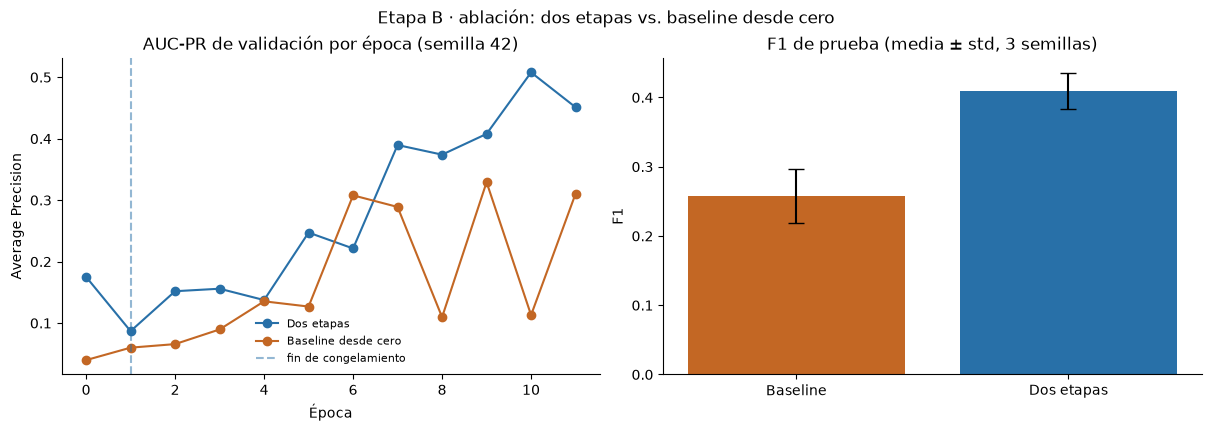

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")
epochs_x = range(len(official_transferred_history.train_loss))
axes[0].plot(epochs_x, official_transferred_history.validation_average_precision, marker="o", color="#2870a8", label="Dos etapas")
axes[0].plot(epochs_x, official_baseline_history.validation_average_precision, marker="o", color="#c36724", label="Baseline desde cero")
axes[0].axvline(official_transferred_history.backbone_frozen_epochs, color="#2870a8", linestyle="--", alpha=.5, label="fin de congelamiento")
axes[0].set(title="AUC-PR de validación por época (semilla 42)", xlabel="Época", ylabel="Average Precision")
axes[0].legend(frameon=False, fontsize=8)

arms = ["Baseline", "Dos etapas"]
f1_means = [np.mean([r["test_f1"] for r in baseline_runs]), np.mean([r["test_f1"] for r in transferred_runs])]
f1_stds = [np.std([r["test_f1"] for r in baseline_runs]), np.std([r["test_f1"] for r in transferred_runs])]
axes[1].bar(arms, f1_means, yerr=f1_stds, color=["#c36724", "#2870a8"], capsize=6)
axes[1].set(title="F1 de prueba (media ± std, 3 semillas)", ylabel="F1")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Etapa B · ablación: dos etapas vs. baseline desde cero")
fig.savefig(REPORT_DIR_C2B / "ablacion.png", dpi=160)
plt.show()

**Limitación honesta:** con solo 254 remitentes positivos en entrenamiento y 54 en prueba, hay varianza real entre semillas. El hallazgo de que la configuración de transfer learning importa tanto como su sola presencia —una configuración mal calibrada puede perder frente a un baseline, como se documentó arriba— es en sí mismo un resultado que vale la pena reportar, no solo un paso intermedio a descartar.

In [22]:
save_stage_b_checkpoint(
    STAGE_B_CHECKPOINT_PATH, official_transferred_model, stage_a_config,
    StageBConfig(seed=42, use_stage_a_score=True), official_transferred_threshold,
    transferred=True, history=official_transferred_history,
)
save_stage_b_checkpoint(
    STAGE_B_BASELINE_CHECKPOINT_PATH, official_baseline_model, stage_a_config,
    StageBConfig(seed=42, use_stage_a_score=False), official_baseline_threshold,
    transferred=False, history=official_baseline_history,
)
print(f"Checkpoints (semilla 42) guardados en {STAGE_B_CHECKPOINT_PATH.name} y {STAGE_B_BASELINE_CHECKPOINT_PATH.name}")

Checkpoints (semilla 42) guardados en stage_b_transferred.pt y stage_b_baseline.pt


## Interpretabilidad: 5 casos del conjunto de prueba

Tres verdaderos positivos, un falso positivo y un falso negativo, seleccionados con el modelo oficial (semilla 42). Los pesos de atención son los del pooling de la Etapa B, alineados con `transaction_ids`. Análisis completo en `report/interpretabilidad_casos.md`.

In [23]:
test_scores_b = score_loader_stage_b(official_transferred_model, loaders["test"], device, stage_a_model)
pred_b = (test_scores_b["probability"] > official_transferred_threshold.threshold).astype(int)
y_b = test_scores_b["y"].astype(int)
sender_ids_b = test_scores_b["sender_id"]

tp_idx = np.flatnonzero((pred_b == 1) & (y_b == 1))
fp_idx = np.flatnonzero((pred_b == 1) & (y_b == 0))
fn_idx = np.flatnonzero((pred_b == 0) & (y_b == 1))
print(f"Verdaderos positivos: {len(tp_idx)} · Falsos positivos: {len(fp_idx)} · Falsos negativos: {len(fn_idx)}")

case_rng = np.random.default_rng(42)
case_ids = [
    *[("Verdadero positivo", sender_ids_b[i]) for i in case_rng.choice(tp_idx, size=3, replace=False)],
    ("Falso positivo", sender_ids_b[case_rng.choice(fp_idx, size=1, replace=False)[0]]),
    ("Falso negativo", sender_ids_b[case_rng.choice(fn_idx, size=1, replace=False)[0]]),
]

Verdaderos positivos: 20 · Falsos positivos: 19 · Falsos negativos: 34


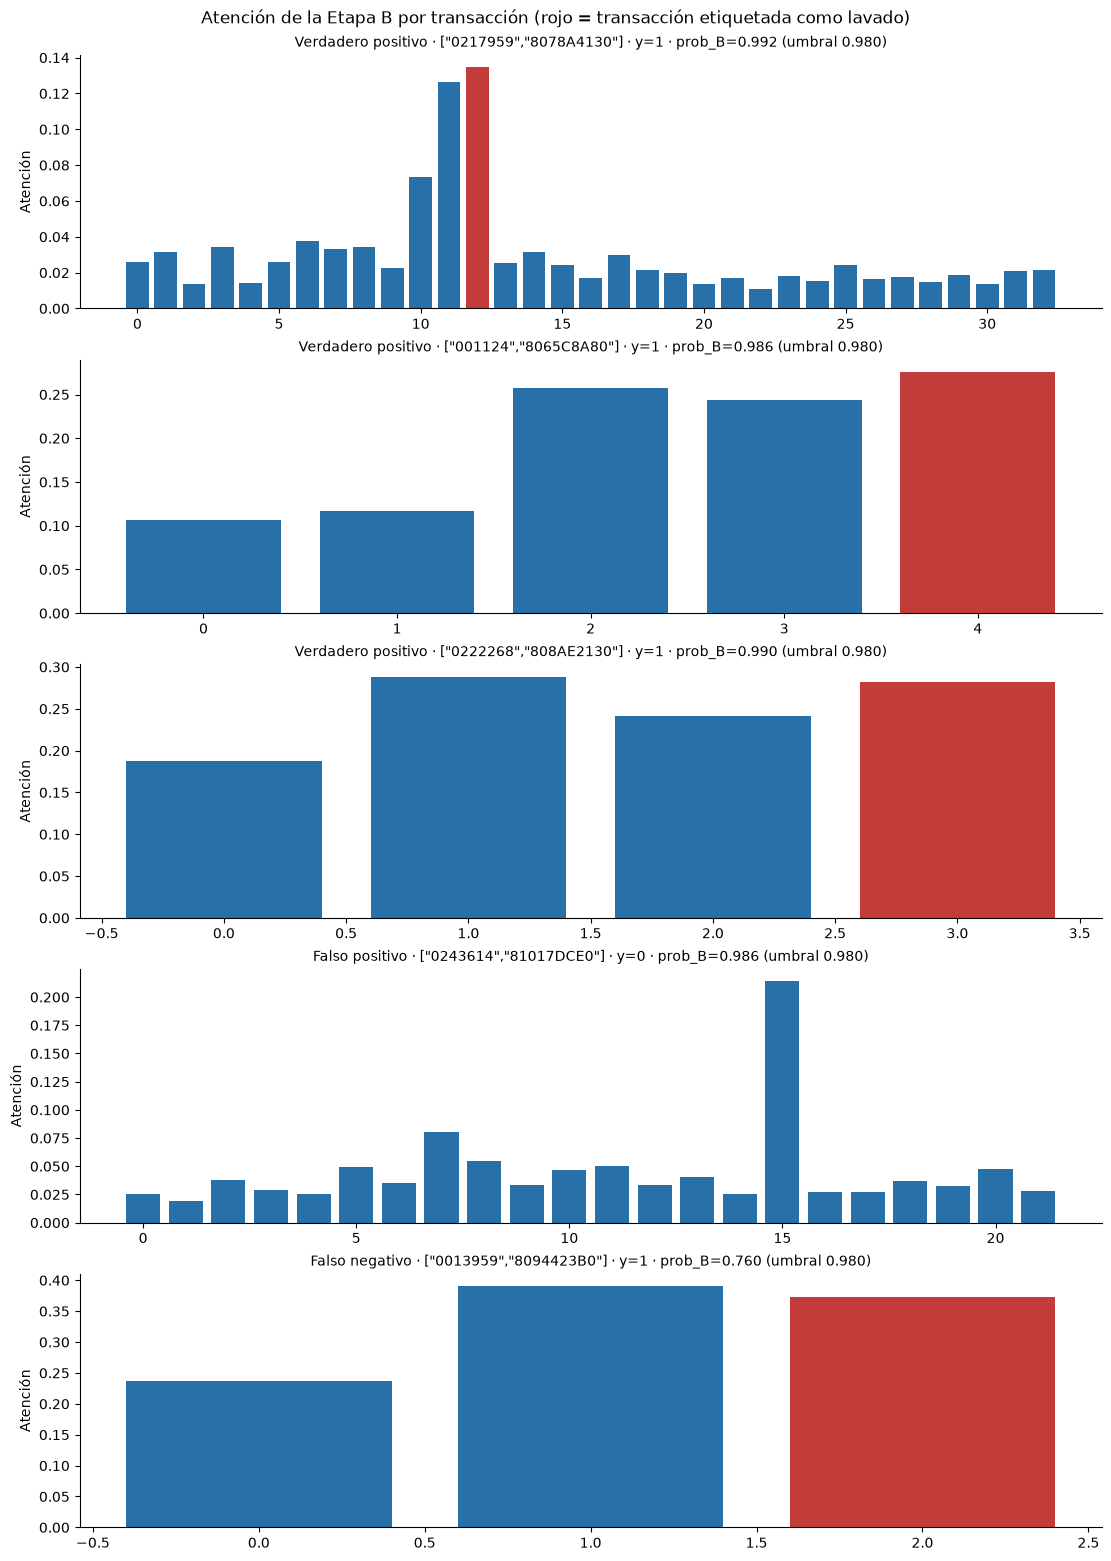

In [24]:
fig, axes = plt.subplots(len(case_ids), 1, figsize=(11, 3.1 * len(case_ids)), layout="constrained")
for panel, (category, case_sender_id) in zip(axes, case_ids):
    case_batch = get_sender(case_sender_id, ARTIFACT_DIR, split="test")
    case_prediction = predict_stage_b_batch(official_transferred_model, case_batch, device, stage_a_model)
    case_frame = pd.DataFrame(case_batch["transactions"])
    case_frame["atención_etapa_b"] = case_prediction["attention"]
    colors = ["#c43c39" if row.is_laundering else "#2870a8" for row in case_frame.itertuples()]
    panel.bar(range(len(case_frame)), case_frame["atención_etapa_b"], color=colors)
    panel.set_title(
        f"{category} · {case_sender_id} · y={int(case_batch['y'].item())} · "
        f"prob_B={float(case_prediction['probability'][0]):.3f} (umbral {official_transferred_threshold.threshold:.3f})",
        fontsize=10,
    )
    panel.set_ylabel("Atención")
    panel.spines[["top", "right"]].set_visible(False)
fig.suptitle("Atención de la Etapa B por transacción (rojo = transacción etiquetada como lavado)")
fig.savefig(REPORT_DIR_C2B / "casos_interpretabilidad.png", dpi=150)
plt.show()

# Interpretabilidad e integración del MVP

Las filas de `get_sender` mantienen el orden del tensor, lo que permite alinear atención, heatmap y explicación. El MVP (`app/streamlit_app.py`, `src/inference.py`) integra ambas etapas: cuando existe un checkpoint de la Etapa B (`app/model/stage_b.pt`), `src.inference.run_stage_b` deja de devolver `None` y el MVP muestra automáticamente la probabilidad combinada, el mapa de calor de la Etapa B y la explicación en lenguaje natural con ambas señales, sin cambios en la interfaz.